In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv('adult_with_headers.csv')
df.head(10)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [80]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [81]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [82]:
df.shape

(32561, 15)

In [83]:
for col in ['workclass','occupation','native_country']:
    print(col)
    print(df[col].value_counts())
    print("-" * 30)

workclass
workclass
 Private             22696
 Self-emp-not-inc     2541
 Local-gov            2093
 ?                    1836
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: count, dtype: int64
------------------------------
occupation
occupation
 Prof-specialty       4140
 Craft-repair         4099
 Exec-managerial      4066
 Adm-clerical         3770
 Sales                3650
 Other-service        3295
 Machine-op-inspct    2002
 ?                    1843
 Transport-moving     1597
 Handlers-cleaners    1370
 Farming-fishing       994
 Tech-support          928
 Protective-serv       649
 Priv-house-serv       149
 Armed-Forces            9
Name: count, dtype: int64
------------------------------
native_country
native_country
 United-States                 29170
 Mexico                          643
 ?                               583
 Philippines                     198
 Germany          

In [84]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

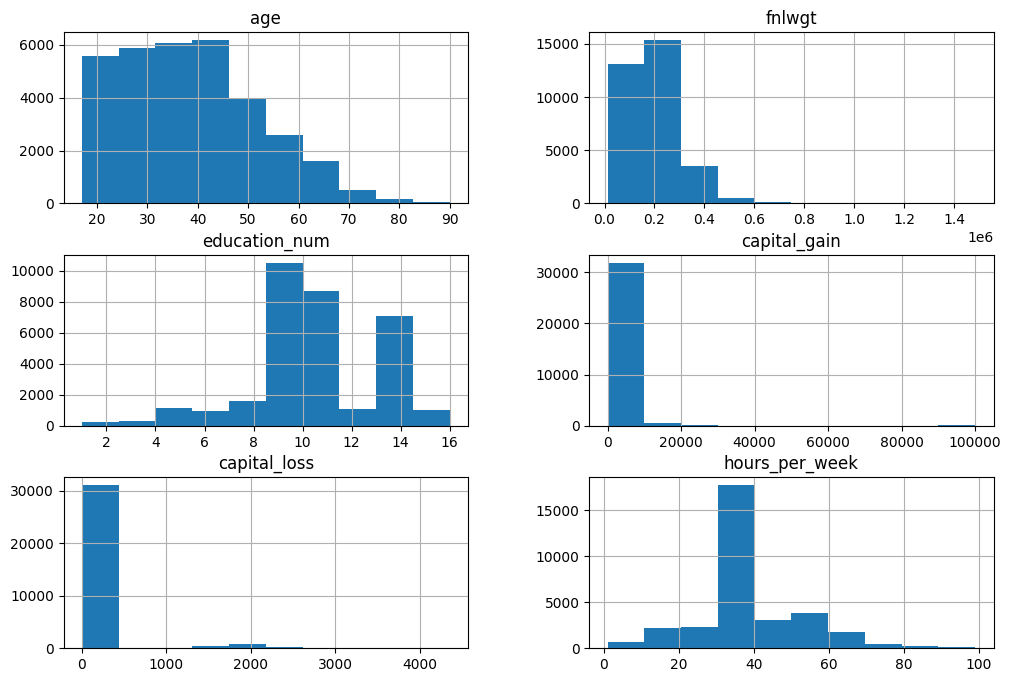

In [85]:
df[num_cols].hist(figsize=(12,8))
plt.show()

you can see in the above disrtibution that most of the people are young, and could be the working age people. there are some extreme values in age as well since some people are working even in their old age. it reflects a  real life scenario. fnlwgt column have unclear meaning and  and have very large values in this . capital gain column also had very few extreame values but also had values mostly zero's.  capital loss have the same pattern as capital gain since there are mostly 0's and some having large extreme values. This may dominate the model we need to take care of them.

In [86]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [87]:
for col in cat_cols:
    print(f'\n column:{col}')
    print(df[col].unique()[:10])


 column:workclass
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']

 column:education
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate']

 column:marital_status
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']

 column:occupation
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct']

 column:relationship
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']

 column:race
[' White' ' Black' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo' ' Other']

 column:sex
[' Male' ' Female']

 column:native_country
[' United-States' ' Cuba' ' Jamaica' ' India' ' ?' ' Mexico' ' South'
 ' Puerto-Rico' ' Honduras' ' England']

 column

In [88]:
# Strip leading/trailing whitespace from all string columns
df_obj = df.select_dtypes(['object'])
df[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())

In [89]:
(df == '?').sum().sort_values(ascending=False)

occupation        1843
workclass         1836
native_country     583
age                  0
fnlwgt               0
education            0
education_num        0
marital_status       0
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
income               0
dtype: int64

as you can see there are some missing values filled as ' ?' in some categorical columns. we need to take care of them before moving forward

In [90]:
df.replace("?", np.nan, inplace=True)

In [91]:
df['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [92]:
df.isnull().sum().sort_values(ascending=False)

occupation        1843
workclass         1836
native_country     583
age                  0
fnlwgt               0
education            0
education_num        0
marital_status       0
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
income               0
dtype: int64

Now you can see there are clear missing values that pandas was unable to identify due to it being filled with '?'. it also had some leading spaces we removed manually. now we can work on the  missing value treatment.

In [93]:
missing_count = df.isnull().sum()
missing_percent =(df.isna().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending= False)

In [94]:
missing_df

,Missing_count,missing_percent
occupation,1843,5.660146
workclass,1836,5.638647
native_country,583,1.790486
age,0,0.000000
fnlwgt,0,0.000000
education,0,0.000000
education_num,0,0.000000
marital_status,0,0.000000
relationship,0,0.000000
race,0,0.000000


 you can see that in occupation and workclass there are the most missing values here. and native country also had some missing values.

In [95]:
df["occupation_missing"] = df["occupation"].isnull()

# Compare income distribution
pd.crosstab(df["occupation_missing"], df["income"], normalize="index")


income,<=50K,>50K
occupation_missing,,
False,0.750960,0.249040
True,0.896365,0.103635


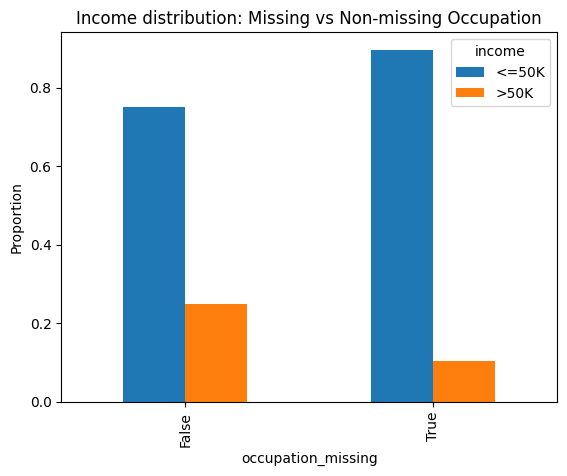

In [96]:
pd.crosstab(df["occupation_missing"], df["income"], normalize="index") \
  .plot(kind="bar")

plt.title("Income distribution: Missing vs Non-missing Occupation")
plt.ylabel("Proportion")
plt.show()


from above chart we can understand that people who's occupation is missing has income less than <50K. doing imputation techniques   here would be a not beneficial , if done we could lose valuable data and can create a bias.
so missing occupation is not random it is associated with lower income.

In [97]:
# Create missing flag
df["workclass_missing"] = df["workclass"].isnull()

# Crosstab to compare income distribution
pd.crosstab(
    df["workclass_missing"],
    df["income"],
    normalize="index"
)


income,<=50K,>50K
workclass_missing,,
False,0.751017,0.248983
True,0.895969,0.104031


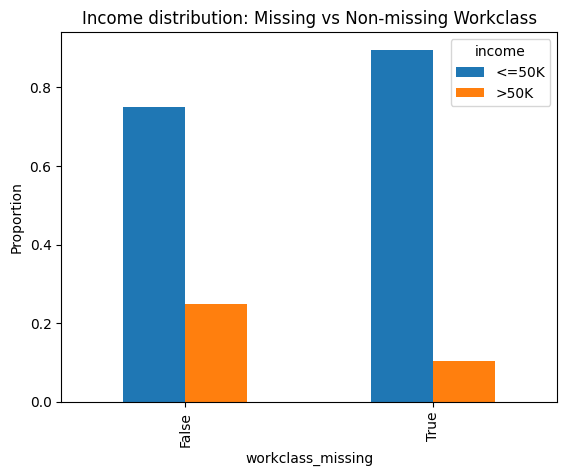

In [98]:
pd.crosstab(
    df["workclass_missing"],
    df["income"],
    normalize="index"
).plot(kind="bar")

import matplotlib.pyplot as plt
plt.title("Income distribution: Missing vs Non-missing Workclass")
plt.ylabel("Proportion")
plt.show()


you can see in here that when workclass is missing the missingness i is among the people who earn less than  <50k. it is identical to occupation column missing distribution.

In [99]:
# Create missing flag
df["native_country_missing"] = df["native_country"].isnull()

# Crosstab
pd.crosstab(
    df["native_country_missing"],
    df["income"],
    normalize="index"
)


income,<=50K,>50K
native_country_missing,,
False,0.759366,0.240634
True,0.749571,0.250429


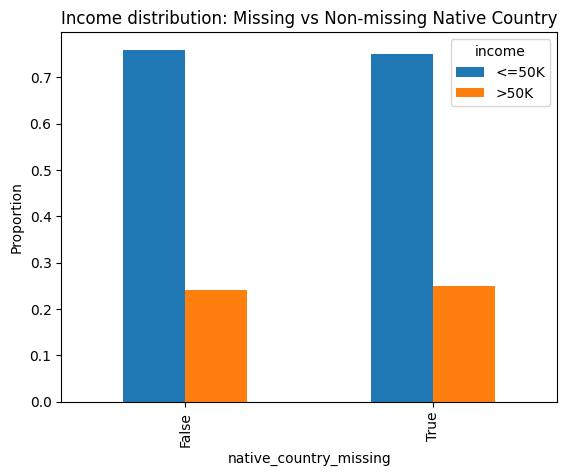

In [100]:
pd.crosstab(
    df["native_country_missing"],
    df["income"],
    normalize="index"
).plot(kind="bar")

plt.title("Income distribution: Missing vs Non-missing Native Country")
plt.ylabel("Proportion")
plt.show()


in above visual the missingness is almost same as non missing. this can be random missingness. seeing it is similar in both cases. so mode imputation here is unlikely to bias our model.

In [101]:
df["occupation"] = df["occupation"].fillna("Missing")
df["workclass"] = df["workclass"].fillna("Missing")

In [102]:
country_mode = df['native_country'].mode()[0]
df['native_country'] = df['native_country'].fillna(country_mode)

In [103]:
df.isnull().sum()

age                       0
workclass                 0
fnlwgt                    0
education                 0
education_num             0
marital_status            0
occupation                0
relationship              0
race                      0
sex                       0
capital_gain              0
capital_loss              0
hours_per_week            0
native_country            0
income                    0
occupation_missing        0
workclass_missing         0
native_country_missing    0
dtype: int64

In [104]:
df.drop(columns=['fnlwgt'], inplace=True)

In [105]:
num_cols = [
    "age",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]


In [106]:
df.dtypes

age                        int64
workclass                 object
education                 object
education_num              int64
marital_status            object
occupation                object
relationship              object
race                      object
sex                       object
capital_gain               int64
capital_loss               int64
hours_per_week             int64
native_country            object
income                    object
occupation_missing          bool
workclass_missing           bool
native_country_missing      bool
dtype: object

now we have filled the missing rows with 'missing' for occupation and workclass. we have also imputed the native country column with mode since in that particular column the missingness is random. 

# Feature scaling

In [107]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [109]:
scaler = StandardScaler()
df_std =df.copy()
df_std[num_cols] =scaler.fit_transform(df[num_cols])

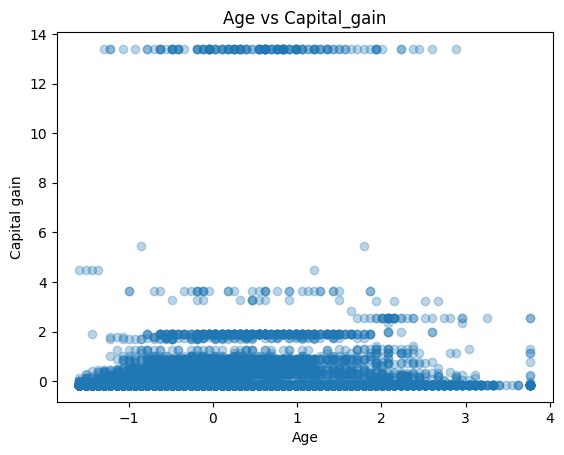

In [110]:
plt.scatter(df_std["age"], df_std["capital_gain"], alpha=0.3)
plt.xlabel("Age")
plt.ylabel("Capital gain")
plt.title("Age vs Capital_gain")
plt.show()


In [111]:
df_std[num_cols].describe()

,age,education_num,capital_gain,capital_loss,hours_per_week
count,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04
mean,-2.705915e-17,1.471887e-16,1.309314e-17,1.016900e-16,-1.549355e-17
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-1.582206e+00,-3.529656e+00,-1.459205e-01,-2.166595e-01,-3.194030e+00
25%,-7.757679e-01,-4.200596e-01,-1.459205e-01,-2.166595e-01,-3.542945e-02
50%,-1.159546e-01,-3.136003e-02,-1.459205e-01,-2.166595e-01,-3.542945e-02
75%,6.904838e-01,7.460392e-01,-1.459205e-01,-2.166595e-01,3.695194e-01
max,3.769612e+00,2.300838e+00,1.339458e+01,1.059351e+01,4.742967e+00


In [112]:
minmax = MinMaxScaler()
df_mm = df.copy()
df_mm[num_cols] = minmax.fit_transform(df[num_cols])

In [113]:
df_mm[num_cols].describe()

,age,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,0.295639,0.605379,0.010777,0.020042,0.402423
std,0.186855,0.171515,0.073854,0.092507,0.125994
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.533333,0.000000,0.000000,0.397959
50%,0.273973,0.600000,0.000000,0.000000,0.397959
75%,0.424658,0.733333,0.000000,0.000000,0.448980
max,1.000000,1.000000,1.000000,1.000000,1.000000


Numerical features had vastly different ranges , which could have biased our models. Therefore we applied Standard scaler and minmax scaler  to bring the measures on similar scale. Standard scaler was used to ceter features around zero with unit variance , while minmax normalized features into 0,1 range. We now know that the dominance of high magnitude features is no more.

Standardscaler or z score normalization is prefered when machine leanring algorithm assumes that features are centered around 0 and have comparable variance or have mean of 0 and std_dev of 1. It is especially usefull for the models that rely on distance or linear relationships, such as linear regression , logistic regression, SVM, and PCA. Standard scaling preserves the shape of the disrtribution while removing the scale differences, making suitable features follow approximately normal distribution .

In Min max scaler , it is prefered when features need to be bound in specific  fixed range typically 0 to 1. it is commanly used in neaural networks, k nearest neighbors and gradient based models. Min max scaling is also usefull when data does not follow a normal distribution and when preserving the relative ordering of values is more important that centering around the mean.

# Encoding

In [114]:
cat_cols

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [115]:
df['income'] = df['income'].map({'<=50K':0, '>50K':1})
df['income'].value_counts(normalize=True)

income
0    0.75919
1    0.24081
Name: proportion, dtype: float64

In [116]:
df.select_dtypes(include='object').nunique().sort_values()

sex                2
race               5
relationship       6
marital_status     7
workclass          9
occupation        15
education         16
native_country    41
dtype: int64

In [117]:
one_hot_cols = ['sex', 'race']

df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)# applying one hot encoding

In [118]:
from sklearn.preprocessing import LabelEncoder

label_encode = LabelEncoder()
label_cols = [
    'relationship', 'marital_status',
    'workclass', 'occupation', 'native_country'
]

for col in label_cols:
    df[col] = label_encode.fit_transform(df[col])


In [119]:
df

,age,workclass,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,income,occupation_missing,workclass_missing,native_country_missing,sex_Male,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,7,Bachelors,13,4,0,1,2174,0,40,38,0,False,False,False,True,False,False,False,True
1,50,6,Bachelors,13,2,3,0,0,0,13,38,0,False,False,False,True,False,False,False,True
2,38,4,HS-grad,9,0,5,1,0,0,40,38,0,False,False,False,True,False,False,False,True
3,53,4,11th,7,2,5,0,0,0,40,38,0,False,False,False,True,False,True,False,False
4,28,4,Bachelors,13,2,10,5,0,0,40,4,0,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,Assoc-acdm,12,2,13,5,0,0,38,38,0,False,False,False,False,False,False,False,True
32557,40,4,HS-grad,9,2,6,0,0,0,40,38,1,False,False,False,True,False,False,False,True
32558,58,4,HS-grad,9,6,0,4,0,0,40,38,0,False,False,False,False,False,False,False,True
32559,22,4,HS-grad,9,4,0,3,0,0,20,38,0,False,False,False,True,False,False,False,True


In [120]:
df.drop(columns=['education'])

,age,workclass,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,income,occupation_missing,workclass_missing,native_country_missing,sex_Male,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,39,7,13,4,0,1,2174,0,40,38,0,False,False,False,True,False,False,False,True
1,50,6,13,2,3,0,0,0,13,38,0,False,False,False,True,False,False,False,True
2,38,4,9,0,5,1,0,0,40,38,0,False,False,False,True,False,False,False,True
3,53,4,7,2,5,0,0,0,40,38,0,False,False,False,True,False,True,False,False
4,28,4,13,2,10,5,0,0,40,4,0,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,12,2,13,5,0,0,38,38,0,False,False,False,False,False,False,False,True
32557,40,4,9,2,6,0,0,0,40,38,1,False,False,False,True,False,False,False,True
32558,58,4,9,6,0,4,0,0,40,38,0,False,False,False,False,False,False,False,True
32559,22,4,9,4,0,3,0,0,20,38,0,False,False,False,True,False,False,False,True


we applied the encoding techniques based on categorical cardinality as specified in the assignment, balancing dimentionality and computational efficiency while acknowleding the potential of label encoding.

# feature engineering

In [121]:
df['capital_activity'] = ((df['capital_gain']> 0) | (df['capital_loss']> 0)).astype(int)

In [122]:
df.groupby('capital_activity')['income'].mean()

capital_activity
0    0.190293
1    0.579059
Name: income, dtype: float64

capital activity captures whether an individual participates in capital related financial activities, 0 indicates lower capital activity and 1 indicates higher activity.

In [123]:
df['work_intensity'] = (df['hours_per_week'] > 40).astype(int)
df.groupby('work_intensity')['income'].mean()

work_intensity
0    0.173412
1    0.402463
Name: income, dtype: float64

the above feature differentiates individual working beyond standard full time hours, which may correlate with higher earning or overtime based compensations.

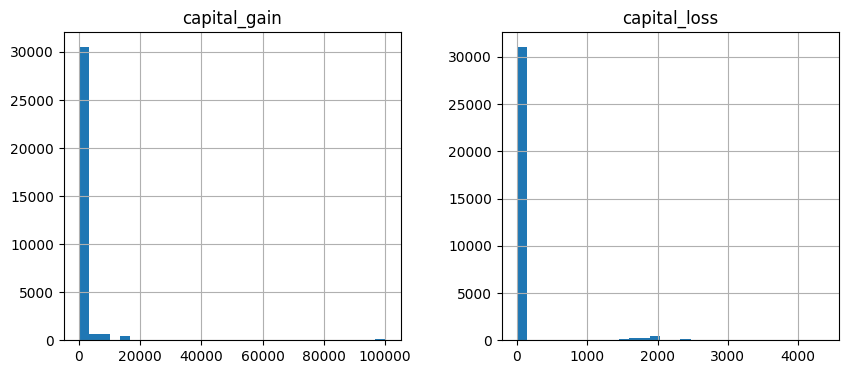

In [124]:
df[['capital_gain', 'capital_loss']].hist(bins= 30 , figsize=(10,4))
plt.show()

you can see the huge spike at o which indicates that it is extremely skewed towards right.

In [125]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

In [126]:
df['capital_loss_log'] = np.log1p(df['capital_loss'])

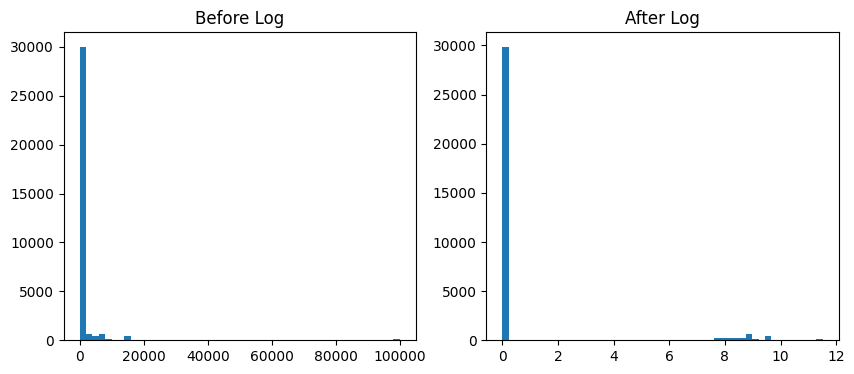

In [127]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].hist(df['capital_gain'], bins=50)
ax[0].set_title('Before Log')

ax[1].hist(df['capital_gain_log'], bins=50)
ax[1].set_title('After Log')

plt.show()


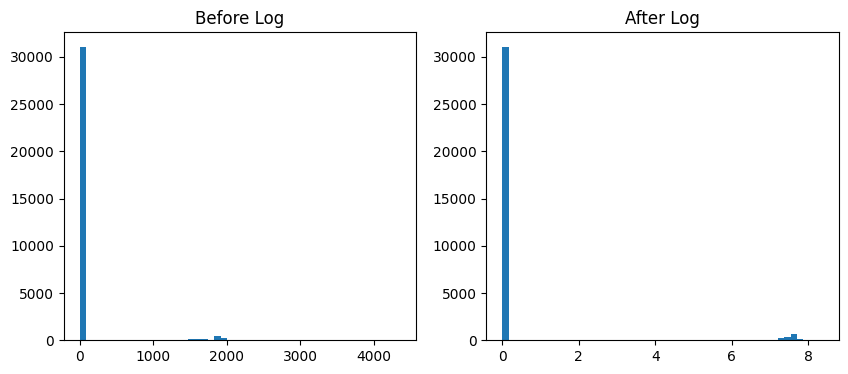

In [128]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].hist(df['capital_loss'], bins=50)
ax[0].set_title('Before Log')

ax[1].hist(df['capital_loss_log'], bins=50)
ax[1].set_title('After Log')

plt.show()

you can see after the log transformation successfully reduced and compressed the data. this reduces the skewness and limits influence of outliers, enabling the model to learn more stable relationships.

# feature selection

In [129]:
from sklearn.ensemble import IsolationForest

In [130]:
iso_features = ['age','education_num','capital_gain_log',
              'capital_loss_log','hours_per_week']

In [131]:
iso = IsolationForest(
    contamination = 0.02,
    random_state=42
)

df['outlier'] = iso.fit_predict(df[iso_features])

In [132]:
df['outlier'].value_counts()

outlier
 1    31909
-1      652
Name: count, dtype: int64

In [133]:
df.groupby('outlier')['income'].mean()

outlier
-1    0.500000
 1    0.235513
Name: income, dtype: float64

In [134]:
df_clean =df[df['outlier']== 1].drop(columns=['outlier'])

In [135]:
df_clean = df_clean.drop(columns=['education'])

In [136]:
df_clean

,age,workclass,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,...,native_country_missing,sex_Male,race_Asian-Pac-Islander,race_Black,race_Other,race_White,capital_activity,work_intensity,capital_gain_log,capital_loss_log
0,39,7,13,4,0,1,2174,0,40,38,...,False,True,False,False,False,True,1,0,7.684784,0.0
1,50,6,13,2,3,0,0,0,13,38,...,False,True,False,False,False,True,0,0,0.000000,0.0
2,38,4,9,0,5,1,0,0,40,38,...,False,True,False,False,False,True,0,0,0.000000,0.0
3,53,4,7,2,5,0,0,0,40,38,...,False,True,False,True,False,False,0,0,0.000000,0.0
4,28,4,13,2,10,5,0,0,40,4,...,False,False,False,True,False,False,0,0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,12,2,13,5,0,0,38,38,...,False,False,False,False,False,True,0,0,0.000000,0.0
32557,40,4,9,2,6,0,0,0,40,38,...,False,True,False,False,False,True,0,0,0.000000,0.0
32558,58,4,9,6,0,4,0,0,40,38,...,False,False,False,False,False,True,0,0,0.000000,0.0
32559,22,4,9,4,0,3,0,0,20,38,...,False,True,False,False,False,True,0,0,0.000000,0.0


isolation forest identified approximately 2 % of observations as outliers. these instances exhibit a significantly higher proportion of high income individuals compared to the rest of the dataset, indicating that extreme values could disproportionately influence model learning. threfore we remove the outliers to improve the model stability.

Predictive Power Score (PPS) was used to assess the predictive strength of features with respect to the target variable and was compared against the correlation matrix to highlight non-linear and asymmetric relationships.